-- Here we go

1. Data Exploration
   - Null Values
   - Duplicate Values
   - Explore each column (values)

2. Data Cleaning
   - Remove Null
   - Remove Unwanted Columns
   - Remove Duplicates
   - Change Datatypes of Columns

3. Feature Engineering
   - Converting Categorical data to Numeric
   - Combining the Columns
   - Finding Correlation
   - Remove Columns as per the correlation data
   - Data Normalization
   - Split the data into Train & Test

4. AI Model
   - Define the Model
   - Training
   - Model Evaluation

#Understanding titanic dataset for survival prediction

1) Data Cleaning

In [51]:
import pandas as pd


In [52]:
df = pd.read_csv('/content/data.csv')

In [53]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [55]:

del df['PassengerId']
del df['Ticket']
del df['Fare']

In [56]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Cabin,687
Embarked,2


Cabin column is of no further use as it has 687 out of 891 rows empty

In [57]:
del df['Cabin']

But we can not delete the age column as its one of the crucial info. we need for our model
So  instead of deleting it we might add an avg. value in those null rows

In [58]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [59]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Embarked,2


Now Embarked has only 2 rows that are empty so can remove those rows .
it will not effect our dataset

In [60]:
df = df.dropna()

In [61]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Embarked,0


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Name      889 non-null    object 
 3   Sex       889 non-null    object 
 4   Age       889 non-null    float64
 5   SibSp     889 non-null    int64  
 6   Parch     889 non-null    int64  
 7   Embarked  889 non-null    object 
dtypes: float64(1), int64(4), object(3)
memory usage: 62.5+ KB


age should not be a float data type

In [63]:
df['Age'] = df['Age'].astype(int)

/tmp/ipykernel_2399/4210971486.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'] = df['Age'].astype(int)


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Survived  889 non-null    int64 
 1   Pclass    889 non-null    int64 
 2   Name      889 non-null    object
 3   Sex       889 non-null    object
 4   Age       889 non-null    int64 
 5   SibSp     889 non-null    int64 
 6   Parch     889 non-null    int64 
 7   Embarked  889 non-null    object
dtypes: int64(5), object(3)
memory usage: 62.5+ KB


Exploratory Data Analysis

<Axes: ylabel='count'>

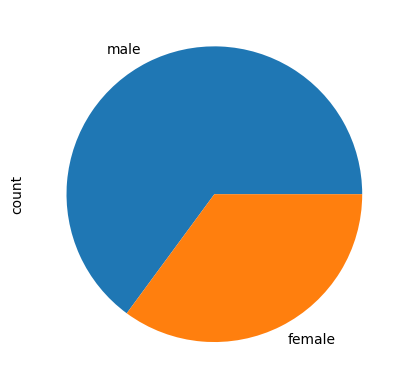

In [65]:
df['Sex'].value_counts().plot(kind='pie')

<Axes: ylabel='count'>

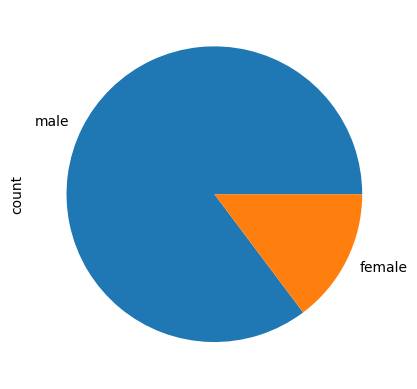

In [66]:
df[df['Survived'] == 0]['Sex'].value_counts().plot(kind = 'pie')

<Axes: ylabel='count'>

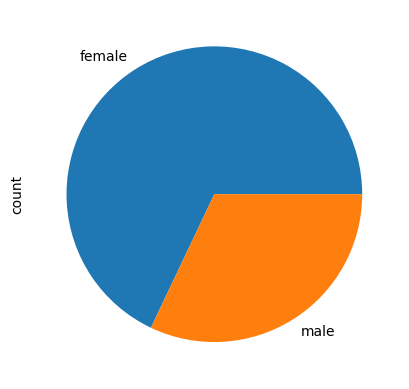

In [67]:
df[df['Survived'] == 1]['Sex'].value_counts().plot(kind = 'pie')

<Axes: ylabel='count'>

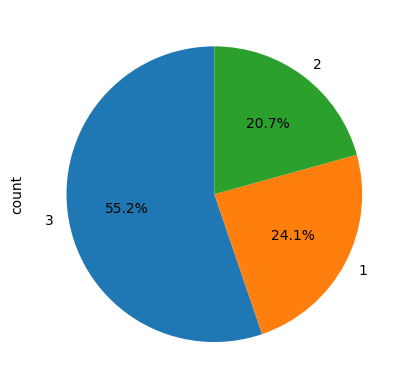

In [68]:
df['Pclass'].value_counts().plot(kind = 'pie' , autopct = '%1.1f%%' , startangle = 90)

<Axes: ylabel='count'>

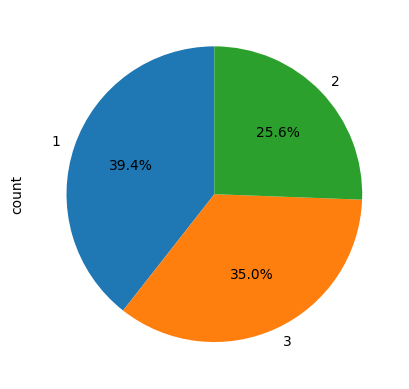

In [69]:
df[df['Survived'] == 1]['Pclass'].value_counts().plot(kind = 'pie' , autopct='%1.1f%%', startangle=90)

<Axes: xlabel='SibSp'>

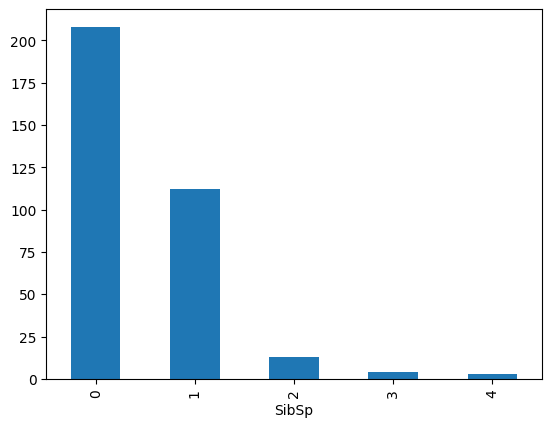

In [70]:
df[df['Survived'] == 1]['SibSp'].value_counts().plot(kind = 'bar')

<Axes: xlabel='SibSp'>

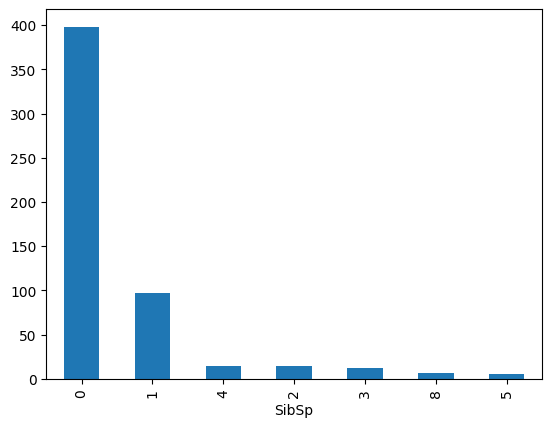

In [71]:
df[df['Survived'] == 0]['SibSp'].value_counts().plot(kind = 'bar')

<Axes: xlabel='SibSp'>

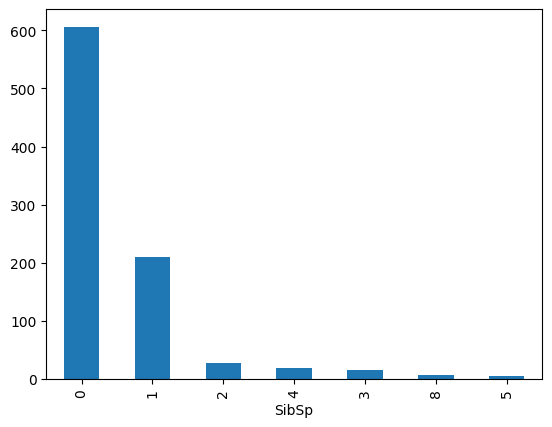

In [72]:
df['SibSp'].value_counts().plot(kind = 'bar')

<Axes: xlabel='Age'>

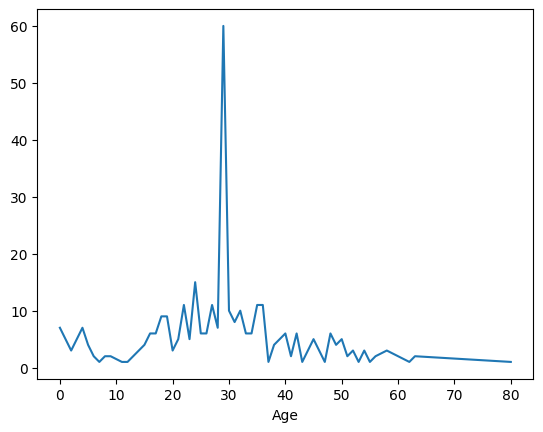

In [73]:
df[df['Survived'] == 1]['Age'].value_counts().sort_index().plot(kind = 'line')

<Axes: xlabel='Age'>

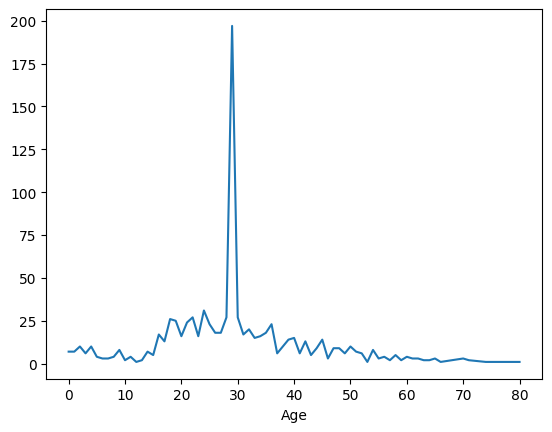

In [74]:
df['Age'].value_counts().sort_index().plot(kind = 'line')

<Axes: ylabel='count'>

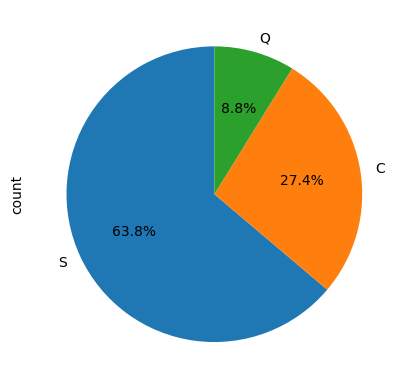

In [75]:
df[df['Survived'] == 1]['Embarked'].value_counts().plot(kind = 'pie' , autopct='%1.1f%%', startangle=90)

<Axes: ylabel='count'>

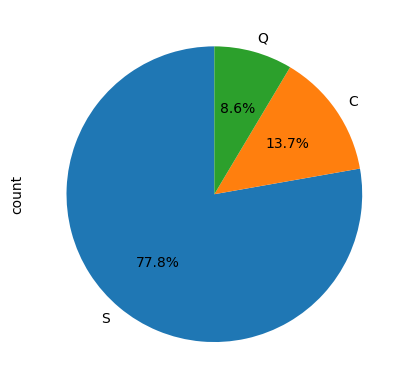

In [76]:
df[df['Survived'] == 0]['Embarked'].value_counts().plot(kind = 'pie' , autopct='%1.1f%%', startangle=90)

<Axes: ylabel='count'>

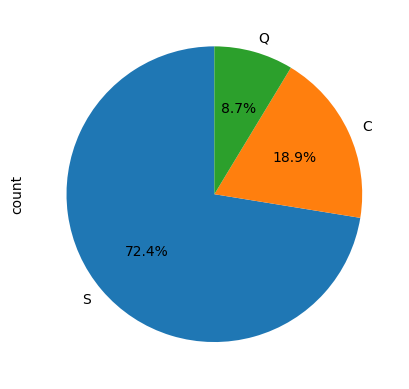

In [77]:
df['Embarked'].value_counts().plot(kind = 'pie' , autopct='%1.1f%%', startangle=90)

## 1) Feature Engineering

Feature engineering is the process of creating, transforming, or modifying features (inputs) so that a Machine Learning model can learn more effectively from the data.

# Here we are transforming the feature data into numerical values so that the evaluation could be faster and easier

In [78]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22,1,0,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,C
2,1,3,"Heikkinen, Miss. Laina",female,26,0,0,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,S
4,0,3,"Allen, Mr. William Henry",male,35,0,0,S
...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27,0,0,S
887,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29,1,2,S
889,1,1,"Behr, Mr. Karl Howell",male,26,0,0,C


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Survived  889 non-null    int64 
 1   Pclass    889 non-null    int64 
 2   Name      889 non-null    object
 3   Sex       889 non-null    object
 4   Age       889 non-null    int64 
 5   SibSp     889 non-null    int64 
 6   Parch     889 non-null    int64 
 7   Embarked  889 non-null    object
dtypes: int64(5), object(3)
memory usage: 62.5+ KB


In [80]:
del df['Name']

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Survived  889 non-null    int64 
 1   Pclass    889 non-null    int64 
 2   Sex       889 non-null    object
 3   Age       889 non-null    int64 
 4   SibSp     889 non-null    int64 
 5   Parch     889 non-null    int64 
 6   Embarked  889 non-null    object
dtypes: int64(5), object(2)
memory usage: 55.6+ KB


In [82]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22,1,0,S
1,1,1,female,38,1,0,C
2,1,3,female,26,0,0,S
3,1,1,female,35,1,0,S
4,0,3,male,35,0,0,S
...,...,...,...,...,...,...,...
886,0,2,male,27,0,0,S
887,1,1,female,19,0,0,S
888,0,3,female,29,1,2,S
889,1,1,male,26,0,0,C


## One hot encoding

One-hot encoding avoids creating the false ordering based on numbers

In [83]:
df = pd.get_dummies(df,columns= ['Sex','Embarked','Pclass'],drop_first=False,dtype=int)
# get_dummies is for one-hot encodiong


In [84]:
df.head()

,Survived,Age,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,0,22,1,0,0,1,0,0,1,0,0,1
1,1,38,1,0,1,0,1,0,0,1,0,0
2,1,26,0,0,1,0,0,0,1,0,0,1
3,1,35,1,0,1,0,0,0,1,1,0,0
4,0,35,0,0,0,1,0,0,1,0,0,1


In [85]:
df.corr()

,Survived,Age,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
Survived,1.000000,-0.072695,-0.034040,0.083151,0.541585,-0.541585,0.169966,0.004536,-0.151777,0.282368,0.095002,-0.320171
Age,-0.072695,1.000000,-0.231992,-0.175770,-0.087839,0.087839,0.032622,-0.020153,-0.015897,0.317901,0.012052,-0.283138
SibSp,-0.034040,-0.231992,1.000000,0.414542,0.116348,-0.116348,-0.060074,-0.026692,0.069438,-0.052894,-0.056507,0.091515
Parch,0.083151,-0.175770,0.414542,1.000000,0.247508,-0.247508,-0.011588,-0.081585,0.061512,-0.015809,-0.001278,0.014634
Sex_female,0.541585,-0.087839,0.116348,0.247508,1.000000,-1.000000,0.084520,0.075217,-0.121405,0.093142,0.066459,-0.134227
Sex_male,-0.541585,0.087839,-0.116348,-0.247508,-1.000000,1.000000,-0.084520,-0.075217,0.121405,-0.093142,-0.066459,0.134227
Embarked_C,0.169966,0.032622,-0.060074,-0.011588,0.084520,-0.084520,1.000000,-0.148646,-0.782613,0.299472,-0.126039,-0.154785
Embarked_Q,0.004536,-0.020153,-0.026692,-0.081585,0.075217,-0.075217,-0.148646,1.000000,-0.499261,-0.154680,-0.127705,0.237035
Embarked_S,-0.151777,-0.015897,0.069438,0.061512,-0.121405,0.121405,-0.782613,-0.499261,1.000000,-0.165022,0.190824,-0.013594
Pclass_1,0.282368,0.317901,-0.052894,-0.015809,0.093142,-0.093142,0.299472,-0.154680,-0.165022,1.000000,-0.287653,-0.625395


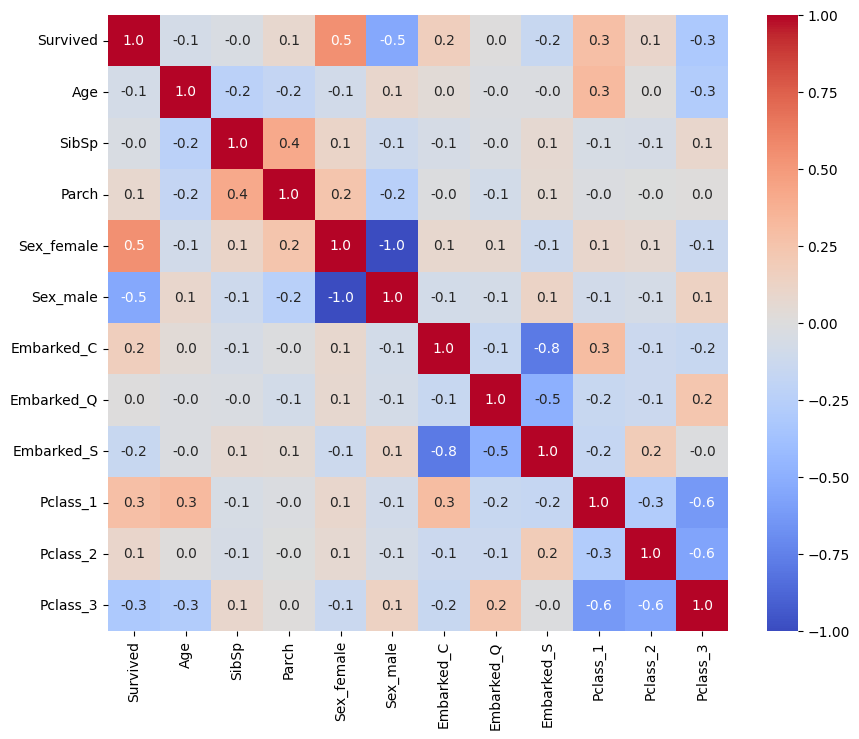

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt=".1f")
plt.show()

#We need to remove the columns that are causing negative correlation as they are unnecessary data (we can remove either one of the columns and the corresponding column will become ineffective)

In [87]:
del df['Embarked_C']   # Removing after analysing correlation
del df['Sex_female']

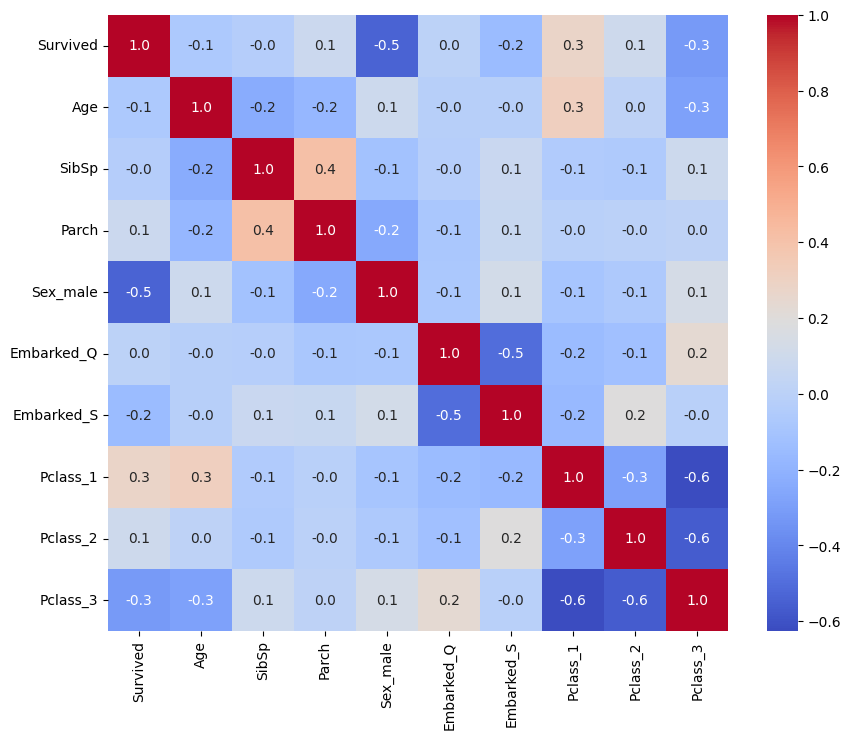

In [88]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt=".1f")
plt.show()

In [89]:
# Combining people columns
df['No.of_peoples'] = df['Parch'] + df['SibSp']

In [90]:
# Deleting after combining
del df['SibSp']
del df['Parch']

In [91]:
# Data Normalisation (to reduce the range of numbers)
df['Age'] = df['Age']/df['Age'].max()
df['No.of_peoples'] = df['No.of_peoples']/df['No.of_peoples'].max()


In [92]:
df.head()

,Survived,Age,Sex_male,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3,No.of_peoples
0,0,0.2750,1,0,1,0,0,1,0.1
1,1,0.4750,0,0,0,1,0,0,0.1
2,1,0.3250,0,0,1,0,0,1,0.0
3,1,0.4375,0,0,1,1,0,0,0.1
4,0,0.4375,1,0,1,0,0,1,0.0


In [93]:
# Unique values in each of the column
for i in df.columns:
  print(i,"->", sorted(df[i].unique()))

Survived -> [np.int64(0), np.int64(1)]
Age -> [np.float64(0.0), np.float64(0.0125), np.float64(0.025), np.float64(0.0375), np.float64(0.05), np.float64(0.0625), np.float64(0.075), np.float64(0.0875), np.float64(0.1), np.float64(0.1125), np.float64(0.125), np.float64(0.1375), np.float64(0.15), np.float64(0.1625), np.float64(0.175), np.float64(0.1875), np.float64(0.2), np.float64(0.2125), np.float64(0.225), np.float64(0.2375), np.float64(0.25), np.float64(0.2625), np.float64(0.275), np.float64(0.2875), np.float64(0.3), np.float64(0.3125), np.float64(0.325), np.float64(0.3375), np.float64(0.35), np.float64(0.3625), np.float64(0.375), np.float64(0.3875), np.float64(0.4), np.float64(0.4125), np.float64(0.425), np.float64(0.4375), np.float64(0.45), np.float64(0.4625), np.float64(0.475), np.float64(0.4875), np.float64(0.5), np.float64(0.5125), np.float64(0.525), np.float64(0.5375), np.float64(0.55), np.float64(0.5625), np.float64(0.575), np.float64(0.5875), np.float64(0.6), np.float64(0.6125)

#Model Training begins


In [94]:
y = df['Survived']
del df['Survived']
x = df

In [95]:
# Now the testing and training data cant't be the same
# So we devide the x,y into the testing and training data

x_train = x[:600]  # We have given 600 rows for training the model
x_test  = x[600:]  # And given rest of the rows for testing the model

# -- Same goes for the label (y)
y_train = y[:600]
y_test  = y[600:]

In [96]:
from sklearn.linear_model import LogisticRegression

# Initiation of the logistic regression model with an increased max_iter
model = LogisticRegression(max_iter=1000)  # optimization Iteration

# Training the model using the feature(x) and target(y)
model.fit(x_train,y_train)

print("I dare you to print \n Logistic_Regression model trained successfully")

I dare you to print 
 Logistic_Regression model trained successfully


In [97]:
# Training Accuracy
accuracy = model.score(x_train,y_train)
print(f"Training Accuracy of the Model: {round( accuracy*100 , 2 )} % " )



# Testing Accuracy
accuracy = model.score(x_test,y_test)
print(f"Testing Accuracy of the Model  : {round( accuracy*100 , 2 )} % " )


Training Accuracy of the Model: 80.5 % 
Testing Accuracy of the Model  : 79.58 % 
